# 🛡️ VerifAI — Content Authenticity Verification Pipeline
> **End-to-End Detection of Deepfakes, Misinformation & Out-of-Context Media**
>
> This is **NOT** just a deepfake detector. It catches:
> - 🎭 **Deepfakes** — face swaps, GAN-generated faces, synthetic video
> - 📰 **Misinformation** — real footage of impossible/fabricated scenarios ("Ronaldo slaps Messi")
> - 🔄 **Out-of-context reuse** — authentic footage presented with false narrative
> - 🗣️ **Voice cloning** — synthetic audio on real-looking video
> - 🖥️ **GAN-generated content** — fully AI-created imagery
>
> ### Pipeline Stages
> | # | Stage | What it detects |
> |---|-------|----------------|
> | 1 | Metadata forensics | Abnormal FPS, codec, duration |
> | 2 | Frame extraction | — |
> | **2.5** | **Semantic plausibility** | **Face ID + CLIP action classification + scene captioning + fact-checking** |
> | 3 | Visual CNN | Pixel-level face manipulation artifacts |
> | 4 | Audio analysis | Synthetic voice characteristics |
> | 5 | FFT frequency analysis | GAN upsampling artifacts |
> | 6 | Grad-CAM XAI | Explainable heatmap of suspicious regions |
>
> **Output:** `report.json` (with manipulation type classification) + `heatmap.jpg` → `/kaggle/working/`

## ⚙️ Cell 1 — Configuration
Set `VIDEO_URL` and `PLATFORM` before running.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# USER CONFIGURATION — Set these before running
# ─────────────────────────────────────────────────────────────────────────────

VIDEO_URL = "/kaggle/input/datasets/ujjwal242005/edited1/lv_7587124129904463157_20260117054413.mp4"   # <── paste your URL here
PLATFORM  = "instagram"   # "instagram" or "youtube"

# ── Cookie authentication (required for most Instagram content) ──────────────
# Option A: Export cookies from your browser using a browser extension
#           (e.g. "Get cookies.txt LOCALLY") and upload the file to Kaggle.
# Option B: On Kaggle, set COOKIES_BROWSER to auto-extract from a browser
#           (only works in local environments, not Kaggle).
COOKIES_FILE    = ""          # path to cookies.txt (Netscape format), e.g. "/kaggle/input/cookies/cookies.txt"
COOKIES_BROWSER = ""          # e.g. "chrome", "firefox" — for local environments only

# Internal paths (Kaggle)
WORK_DIR    = "/kaggle/working/"
VIDEO_PATH  = WORK_DIR + "input_video.mp4"
AUDIO_PATH  = WORK_DIR + "audio.wav"
FRAMES_DIR  = WORK_DIR + "frames/"
HEATMAP_OUT = WORK_DIR + "heatmap.jpg"
REPORT_OUT  = WORK_DIR + "report.json"

FRAME_INTERVAL_SEC = 0.5   # extract one frame every N seconds

import os
os.makedirs(FRAMES_DIR, exist_ok=True)
print("✅ Config loaded. Platform:", PLATFORM)
print("   Video URL:", VIDEO_URL)
if COOKIES_FILE:
    print("   Cookies file:", COOKIES_FILE)
elif COOKIES_BROWSER:
    print("   Cookies from browser:", COOKIES_BROWSER)
else:
    print("   ⚠  No cookies configured — Instagram downloads may fail.")
    print("      Set COOKIES_FILE or COOKIES_BROWSER in Cell 1 for authenticated access.")

✅ Config loaded. Platform: instagram
   Video URL: https://youtube.com/shorts/tshUaSctTNY?si=JTXCULbABaSZGn8d
   ⚠  No cookies configured — Instagram downloads may fail.
      Set COOKIES_FILE or COOKIES_BROWSER in Cell 1 for authenticated access.


## 📦 Cell 2 — Install Dependencies

In [2]:
%%capture
!pip install -q opencv-python-headless librosa mediapipe torch torchvision \
               beautifulsoup4 requests Pillow matplotlib ffmpeg-python yt-dlp \
               transformers accelerate sentencepiece \
               deepface tf-keras open-clip-torch

## 📥 Cell 3 — Platform Detection & Video Download
> **Primary:** yt-dlp with cookie authentication (most reliable)
> **Fallback:** Web scrapers (snapinsta.app, fastdl.app)
>
> ⚠️ Instagram requires login for most content — set `COOKIES_FILE` in Cell 1.

In [3]:
!pip install -q yt-dlp


In [4]:
import requests
from bs4 import BeautifulSoup
import re
import subprocess
import json as _json
from urllib.parse import urlparse, parse_qs, unquote
import warnings

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    )
}

# Suppress SSL warnings when using verify=False as a fallback
warnings.filterwarnings("ignore", message="Unverified HTTPS request")


# ── helpers ──────────────────────────────────────────────────────────────────

def _is_media_url(href: str) -> bool:
    """Return True if *href* looks like a direct video / CDN link."""
    if not href:
        return False
    h = href.lower()
    return any(tok in h for tok in [
        ".mp4", "cdninstagram", "fbcdn.net", "googlevideo", "scontent",
        "video_dashinit", "bytecdn", ".m3u8",
    ])


def _unwrap(href: str) -> str:
    """Decode redirect-wrapper URLs and unescape common patterns."""
    href = href.strip().replace("\\/", "/").replace("&amp;", "&")
    try:
        qs = parse_qs(urlparse(href).query)
        for key in ("url", "u", "target", "dest", "redirect", "redirect_url"):
            if key in qs and qs[key]:
                dec = unquote(qs[key][0])
                if dec.startswith("http") and _is_media_url(dec):
                    return dec
    except Exception:
        pass
    return href


def _find_in_soup(soup: BeautifulSoup):
    """Search parsed HTML for a direct media URL."""
    for a in soup.find_all("a", href=True):
        h = _unwrap(a["href"])
        if h.startswith("http") and _is_media_url(h):
            return h
    for vid in soup.find_all("video"):
        for attr in ("src", "data-src"):
            s = vid.get(attr)
            if s:
                s = _unwrap(s)
                if s.startswith("http") and _is_media_url(s):
                    return s
        src_tag = vid.find("source")
        if src_tag and src_tag.get("src"):
            s = _unwrap(src_tag["src"])
            if s.startswith("http") and _is_media_url(s):
                return s
    for tag in soup.find_all(True):
        for attr in ("src", "data-src", "data-video"):
            s = tag.get(attr)
            if s:
                s = _unwrap(s)
                if s.startswith("http") and _is_media_url(s):
                    return s
    return None


def _find_in_text(text: str):
    """Regex-scan raw response text / scripts for a media URL."""
    patterns = [
        r'https?:\\/\\/[^\s"\'\\]+?\.mp4[^\s"\'\\]*',
        r'https?://[^\s"\'\\]+?\.mp4[^\s"\'\\]*',
        r'"video_url"\s*:\s*"(https?:[^"]+)"',
        r'"contentUrl"\s*:\s*"(https?:[^"]+)"',
        r'"url"\s*:\s*"(https?://[^"]*(?:cdninstagram|fbcdn|scontent)[^"]*)"',
        r'https?://[^\s"\'\\]*(?:cdninstagram|fbcdn\.net|scontent)[^\s"\'\\]*',
    ]
    for p in patterns:
        m = re.search(p, text, re.I)
        if m:
            cand = m.group(1) if m.lastindex else m.group(0)
            cand = _unwrap(cand)
            if cand.startswith("http") and _is_media_url(cand):
                return cand
    return None


def _try_service(sess, home_url, post_url, video_url, errors, verify=True):
    """Generic: fetch token from *home_url*, POST to *post_url*, extract media."""
    try:
        home = sess.get(home_url, headers=HEADERS, timeout=20, verify=verify)
        home.raise_for_status()
        soup = BeautifulSoup(home.text, "html.parser")
        tok = soup.find("input", {"name": "_token"}) or soup.find("input", {"name": "token"})
        token = tok["value"] if tok and tok.has_attr("value") else ""

        payload = {"url": video_url}
        if token:
            payload["_token"] = token

        resp = sess.post(
            post_url,
            data=payload,
            headers={**HEADERS, "Referer": home_url},
            timeout=25,
            verify=verify,
        )
        if resp.status_code >= 400:
            errors.append(f"{post_url} → HTTP {resp.status_code}")
            return None

        # HTML
        result_soup = BeautifulSoup(resp.text, "html.parser")
        cand = _find_in_soup(result_soup)
        if cand:
            return cand

        # JSON
        try:
            cand = _find_in_text(_json.dumps(resp.json()))
            if cand:
                return cand
        except Exception:
            pass

        # raw text
        cand = _find_in_text(resp.text)
        if cand:
            return cand

        errors.append(f"{post_url} → no media URL found in response")
    except requests.exceptions.SSLError as exc:
        # Retry once with SSL verification disabled
        if verify:
            return _try_service(sess, home_url, post_url, video_url, errors, verify=False)
        errors.append(f"{post_url} → SSLError: {exc}")
    except Exception as exc:
        errors.append(f"{post_url} → {type(exc).__name__}: {exc}")
    return None


# ── yt-dlp download (PRIMARY method) ────────────────────────────────────────

def _ytdlp_download(url, output_path, label=""):
    """Use yt-dlp with cookie authentication — the most reliable method."""
    tag = f"[yt-dlp{' ' + label if label else ''}]"
    print(f"  ⬇ {tag} Downloading …")

    cmd = [
        "yt-dlp",
        "--no-check-certificates",
        "-f", "best[ext=mp4]/best",
        "-o", output_path,
        "--no-playlist",
        "--quiet",
        "--no-warnings",
    ]

    # Add cookie authentication
    if COOKIES_FILE and os.path.isfile(COOKIES_FILE):
        cmd.extend(["--cookies", COOKIES_FILE])
        print(f"  🍪 {tag} Using cookies file: {COOKIES_FILE}")
    elif COOKIES_BROWSER:
        cmd.extend(["--cookies-from-browser", COOKIES_BROWSER])
        print(f"  🍪 {tag} Using cookies from browser: {COOKIES_BROWSER}")

    cmd.append(url)

    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=180)
        if result.returncode == 0 and os.path.exists(output_path):
            size_mb = os.path.getsize(output_path) / 1e6
            print(f"  ✅ {tag} Downloaded {size_mb:.1f} MB")
            return True
        else:
            err = (result.stderr or result.stdout or "unknown error").strip()
            # Show the most useful part of the error
            for line in err.split("\n"):
                if "ERROR" in line or "WARNING" in line:
                    print(f"  ⚠  {tag} {line.strip()[:200]}")
                    break
            else:
                print(f"  ⚠  {tag} Failed: {err[:200]}")
            return False
    except subprocess.TimeoutExpired:
        print(f"  ⚠  {tag} Timed out after 180s")
        return False
    except FileNotFoundError:
        print(f"  ⚠  {tag} yt-dlp not installed")
        return False


# ── Web scraper resolvers (FALLBACK) ────────────────────────────────────────

def _resolve_instagram_scrapers(url):
    """Try multiple web scraper services for Instagram. Returns direct URL or None."""
    sess = requests.Session()
    errors = []

    services = [
        ("https://snapinsta.app",       "https://snapinsta.app/api/convert"),
        ("https://fastdl.app/en",       "https://fastdl.app/api/convert"),
        ("https://igdownloader.app",    "https://igdownloader.app/api/convert"),
    ]

    for home, post in services:
        name = urlparse(home).hostname
        print(f"  Trying {name} …")
        cand = _try_service(sess, home, post, url, errors)
        if cand:
            print(f"  ✅ Found download URL via {name}:", cand[:120])
            return cand

    if errors:
        print("  ⚠  All web scrapers failed:")
        for e in errors[-4:]:
            print(f"     • {e[:150]}")
    return None


def resolve_youtube(url):
    """Scrape koutube.com for a direct MP4 download URL."""
    print("[YouTube] Resolving via koutube.com …")
    sess = requests.Session()
    try:
        home = sess.get("https://koutube.com", headers=HEADERS, timeout=15)
        soup = BeautifulSoup(home.text, "html.parser")

        token_inp = soup.find("input", {"name": "_token"}) or soup.find("input", {"name": "token"})
        token = token_inp["value"] if token_inp else ""

        payload = {"url": url}
        if token:
            payload["_token"] = token

        resp = sess.post(
            "https://koutube.com/download",
            data=payload,
            headers={**HEADERS, "Referer": "https://koutube.com/"},
            timeout=20,
        )
        result = BeautifulSoup(resp.text, "html.parser")

        best_url, best_q = None, 0
        for a in result.find_all("a", href=True):
            href = a["href"]
            label = a.get_text(strip=True).lower()
            if not (re.search(r"\.mp4|\.webm", href, re.I) or "googlevideo" in href):
                continue
            for q in [1080, 720, 480, 360, 240, 144]:
                if str(q) in label or str(q) in href:
                    if q > best_q:
                        best_q, best_url = q, href
                    break
            else:
                if best_url is None:
                    best_url = href

        if best_url:
            print(f"  ✅ Found download URL ({best_q}p):", best_url[:80])
            return best_url
    except Exception as e:
        print(f"  ⚠  koutube.com failed: {e}")

    return None   # signal caller to use yt-dlp


def download_video(direct_url, output_path):
    """Stream-download from direct URL to disk."""
    print(f"Downloading video → {output_path}")
    try:
        r = requests.get(direct_url, headers=HEADERS, stream=True, timeout=90, verify=False)
        r.raise_for_status()
    except Exception:
        r = requests.get(direct_url, stream=True, timeout=90, verify=False)
        r.raise_for_status()
    downloaded = 0
    with open(output_path, "wb") as f:
        for chunk in r.iter_content(32768):
            if not chunk:
                continue
            f.write(chunk)
            downloaded += len(chunk)
    print(f"  ✅ Downloaded {downloaded/1e6:.1f} MB")


# ── Run ──────────────────────────────────────────────────────────────────────

print("=" * 60)
print(f"Platform : {PLATFORM}")
print(f"URL      : {VIDEO_URL}")
print("=" * 60)

success = False

if PLATFORM == "instagram":
    # ── Strategy 1: yt-dlp with cookies (BEST for Instagram) ─────────────
    print("\n[Instagram] Strategy 1: yt-dlp with authentication")
    if COOKIES_FILE or COOKIES_BROWSER:
        success = _ytdlp_download(VIDEO_URL, VIDEO_PATH, label="authenticated")
    else:
        print("  ⚠  No cookies configured — trying without auth (may fail)")
        success = _ytdlp_download(VIDEO_URL, VIDEO_PATH, label="no-auth")

    # ── Strategy 2: Web scrapers ─────────────────────────────────────────
    if not success:
        print("\n[Instagram] Strategy 2: Web scraper services")
        # Fast-path: user pasted a direct CDN URL
        if _is_media_url(VIDEO_URL):
            print("  ✅ Input is already a direct media URL")
            download_video(VIDEO_URL, VIDEO_PATH)
            success = True
        else:
            direct_url = _resolve_instagram_scrapers(VIDEO_URL)
            if direct_url:
                try:
                    download_video(direct_url, VIDEO_PATH)
                    success = True
                except Exception as e:
                    print(f"  ⚠  Download failed: {e}")

    # ── Strategy 3: yt-dlp without cookies (last resort) ─────────────────
    if not success and (COOKIES_FILE or COOKIES_BROWSER):
        # We already tried with cookies; skip duplicate
        pass
    elif not success:
        pass  # already tried without cookies above

elif PLATFORM == "youtube":
    # YouTube: try web scraper first, then yt-dlp
    print("\n[YouTube] Strategy 1: koutube.com scraper")
    direct_url = resolve_youtube(VIDEO_URL)
    if direct_url:
        try:
            download_video(direct_url, VIDEO_PATH)
            success = True
        except Exception as e:
            print(f"  ⚠  Download failed: {e}")

    if not success:
        print("\n[YouTube] Strategy 2: yt-dlp")
        success = _ytdlp_download(VIDEO_URL, VIDEO_PATH, label="youtube")
else:
    raise ValueError(f"Unsupported platform: {PLATFORM}")

# ── Final check ──────────────────────────────────────────────────────────────
if not success or not os.path.exists(VIDEO_PATH):
    print("\n" + "=" * 60)
    print("❌ ALL DOWNLOAD METHODS FAILED")
    print("=" * 60)
    print()
    if PLATFORM == "instagram" and not COOKIES_FILE and not COOKIES_BROWSER:
        print("🍪 Instagram requires authentication for most content.")
        print("   To fix this:")
        print("   1. Install a browser extension: 'Get cookies.txt LOCALLY'")
        print("   2. Go to instagram.com and make sure you're logged in")
        print("   3. Click the extension icon → 'Export' → save as cookies.txt")
        print("   4. Upload cookies.txt to Kaggle as a dataset")
        print("   5. Set COOKIES_FILE in Cell 1:")
        print('      COOKIES_FILE = "/kaggle/input/your-dataset/cookies.txt"')
        print()
    raise RuntimeError(
       "All download methods failed.\n"
        "See instructions above for cookie-based authentication."
    )

size_mb = os.path.getsize(VIDEO_PATH) / 1e6
print(f"\n📹 Video saved to: {VIDEO_PATH} ({size_mb:.1f} MB)")

Platform : instagram
URL      : https://youtube.com/shorts/tshUaSctTNY?si=JTXCULbABaSZGn8d

[Instagram] Strategy 1: yt-dlp with authentication
  ⚠  No cookies configured — trying without auth (may fail)
  ⬇ [yt-dlp no-auth] Downloading …
  ✅ [yt-dlp no-auth] Downloaded 0.9 MB

📹 Video saved to: /kaggle/working/input_video.mp4 (0.9 MB)


## 🔬 Cell 4 — Stage 1: Metadata Forensics
Detects abnormal FPS, codec mismatches, and duration inconsistencies.

In [5]:
import cv2
import numpy as np

stage1_findings = []
metadata_score  = 0.0

cap = cv2.VideoCapture(VIDEO_PATH)

fps           = cap.get(cv2.CAP_PROP_FPS)
total_frames  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width         = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height        = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc_int    = int(cap.get(cv2.CAP_PROP_FOURCC))
fourcc_str    = chr(fourcc_int & 0xFF) + chr((fourcc_int >> 8) & 0xFF) + \
               chr((fourcc_int >> 16) & 0xFF) + chr((fourcc_int >> 24) & 0xFF)
duration_sec  = total_frames / fps if fps > 0 else 0
cap.release()

print("─── Metadata ───────────────────────────────")
print(f"  Resolution : {width}x{height}")
print(f"  FPS        : {fps:.2f}")
print(f"  Frames     : {total_frames}")
print(f"  Duration   : {duration_sec:.2f}s")
print(f"  Codec      : {fourcc_str}")

# ── Anomaly scoring ──
anomaly_pts = 0

# Suspiciously non-standard FPS (AI video generators often use exact values)
STANDARD_FPS = [23.976, 24.0, 25.0, 29.97, 30.0, 50.0, 59.94, 60.0]
fps_ok = any(abs(fps - s) < 0.2 for s in STANDARD_FPS)
if not fps_ok:
    anomaly_pts += 2
    stage1_findings.append(f"Unusual FPS detected: {fps:.2f} (not a standard broadcast value)")

# Very short clip (deepfakes often clipped tightly)
if 0 < duration_sec < 2:
    anomaly_pts += 1
    stage1_findings.append(f"Very short clip duration: {duration_sec:.1f}s")

# Unusual aspect ratio (standard: 16:9, 9:16, 1:1, 4:3)
if width > 0 and height > 0:
    ar = width / height
    STANDARD_AR = [16/9, 9/16, 1.0, 4/3]
    ar_ok = any(abs(ar - s) < 0.05 for s in STANDARD_AR)
    if not ar_ok:
        anomaly_pts += 1
        stage1_findings.append(f"Unusual aspect ratio: {ar:.3f}")

metadata_score = min(anomaly_pts / 4.0, 1.0)

print(f"\n⚠  Anomalies : {len(stage1_findings)}")
for f in stage1_findings:
    print("   •", f)
print(f"\n📊 Metadata score: {metadata_score:.2f}")

─── Metadata ───────────────────────────────
  Resolution : 360x640
  FPS        : 30.00
  Frames     : 456
  Duration   : 15.20s
  Codec      : h264

⚠  Anomalies : 0

📊 Metadata score: 0.00


## 🖼️ Cell 5 — Stage 2: Frame Extraction
Extracts one frame every 0.5 seconds using OpenCV.

✅ Extracted 31 frames (every 0.5s)


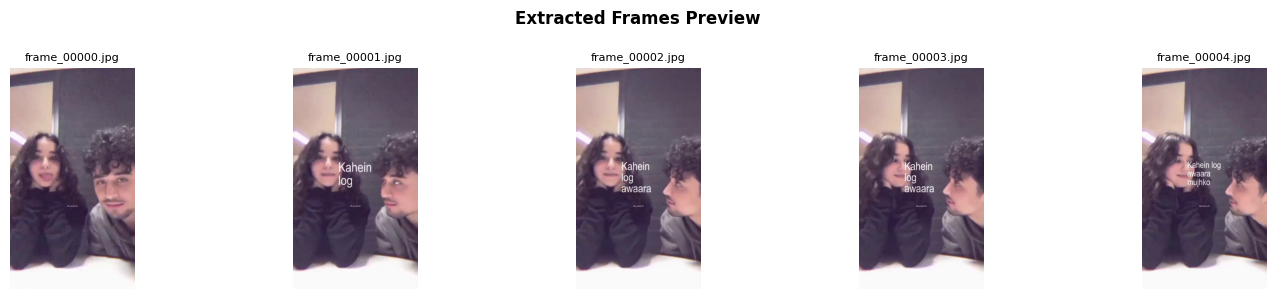

In [6]:
import glob

cap = cv2.VideoCapture(VIDEO_PATH)
fps_v = cap.get(cv2.CAP_PROP_FPS) or 30
frame_step = max(1, int(fps_v * FRAME_INTERVAL_SEC))

frame_paths = []
frame_idx   = 0
saved_idx   = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    if frame_idx % frame_step == 0:
        path = os.path.join(FRAMES_DIR, f"frame_{saved_idx:05d}.jpg")
        cv2.imwrite(path, frame)
        frame_paths.append(path)
        saved_idx += 1
    frame_idx += 1

cap.release()
print(f"✅ Extracted {len(frame_paths)} frames (every {FRAME_INTERVAL_SEC}s)")

# Preview thumbnails
import matplotlib.pyplot as plt
from PIL import Image

preview = frame_paths[:min(5, len(frame_paths))]
fig, axes = plt.subplots(1, len(preview), figsize=(15, 3))
if len(preview) == 1:
    axes = [axes]
for ax, p in zip(axes, preview):
    img = Image.open(p).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(os.path.basename(p), fontsize=8)
plt.suptitle("Extracted Frames Preview", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 🧠 Cell 6 — Stage 2.5: Content Authenticity & Misinformation Detection
This goes **far beyond** deepfake pixel analysis. It answers: **"Is what's depicted in this video even possible?"**

| Module | Model | Purpose |
|--------|-------|---------|
| **A. Face ID** | DeepFace (VGG-Face) | Identify WHO is in the video |
| **B. Scene Captioning** | BLIP | Describe WHAT is happening in each frame |
| **C. Visual Q&A** | BLIP-VQA | Ask targeted questions: *"Is someone being hit?" "Does this look staged?"* |
| **D. Action Classification** | OpenCLIP zero-shot | Classify frame content into 40+ scenario categories |
| **E. Event Likelihood** | OpenCLIP scoring | Score: *"How likely is this exact scenario?"* vs *"How likely is the normal version?"* |
| **F. Plausibility Engine** | Rule engine | Combine all signals → detect impossible events, out-of-context, misinformation |

> 💡 Module E is the key innovation: it uses CLIP to directly measure **how likely** the depicted scenario is
> by comparing the visual evidence against both the "claimed narrative" and its "normal counterpart."
> A frame showing "Ronaldo punching Messi" will score HIGH on the violent description but the
> overall plausibility will be LOW because the *event itself* is impossible.

In [7]:
import torch, os, re, json as _json, urllib.request, shutil
import numpy as np
from PIL import Image
from pathlib import Path
from collections import Counter

# ── Stage 2.5: Content Authenticity & Misinformation Detection ───────────────

stage2_5_findings = []
semantic_score    = 0.0
_captions         = []       # kept for the report
_vqa_answers      = []       # (frame_idx, question, answer)
_identified_faces = []       # (frame_idx, name, confidence)
_clip_labels      = []       # (frame_idx, label, prob)
_event_scores     = []       # (frame_idx, scenario, match_score, normal_score, delta)

print("=" * 60)
print("  🧠  CONTENT AUTHENTICITY & MISINFORMATION ENGINE")
print("=" * 60)

# ── Sample frames for all modules (shared) ───────────────────────────────────
N_SAMPLE = min(10, len(frame_paths))
_sample_indices = np.linspace(0, len(frame_paths) - 1, N_SAMPLE, dtype=int).tolist() if frame_paths else []


# ═══════════════════════════════════════════════════════════════════════════════
# MODULE A — Face Recognition: WHO is in this video?
# ═══════════════════════════════════════════════════════════════════════════════

print("\n── Module A: Face Recognition (DeepFace) ──────────────")

_deepface_ok = False
_gallery_dir = os.path.join(WORK_DIR, "face_gallery")

try:
    from deepface import DeepFace
    _deepface_ok = True
    print("  ✅ DeepFace loaded")
except Exception as e:
    print(f"  ⚠  DeepFace unavailable ({e}) — skipping face ID")

KNOWN_GALLERY = {
    "Cristiano Ronaldo": "https://upload.wikimedia.org/wikipedia/commons/thumb/8/8c/Cristiano_Ronaldo_2018.jpg/440px-Cristiano_Ronaldo_2018.jpg",
    "Lionel Messi":      "https://upload.wikimedia.org/wikipedia/commons/thumb/c/c1/Lionel_Messi_20180626.jpg/440px-Lionel_Messi_20180626.jpg",
    "Donald Trump":      "https://upload.wikimedia.org/wikipedia/commons/thumb/5/56/Donald_Trump_official_portrait.jpg/440px-Donald_Trump_official_portrait.jpg",
    "Joe Biden":         "https://upload.wikimedia.org/wikipedia/commons/thumb/6/68/Joe_Biden_presidential_portrait.jpg/440px-Joe_Biden_presidential_portrait.jpg",
    "Barack Obama":      "https://upload.wikimedia.org/wikipedia/commons/thumb/8/8d/President_Barack_Obama.jpg/440px-President_Barack_Obama.jpg",
    "Elon Musk":         "https://upload.wikimedia.org/wikipedia/commons/thumb/3/34/Elon_Musk_Royal_Society_%28crop2%29.jpg/440px-Elon_Musk_Royal_Society_%28crop2%29.jpg",
    "Taylor Swift":      "https://upload.wikimedia.org/wikipedia/commons/thumb/d/d7/Taylor_Swift_at_the_2023_MTV_Video_Music_Awards_%283%29.png/440px-Taylor_Swift_at_the_2023_MTV_Video_Music_Awards_%283%29.png",
    "Narendra Modi":     "https://upload.wikimedia.org/wikipedia/commons/thumb/c/c3/Narendra_Modi_2021.jpg/440px-Narendra_Modi_2021.jpg",
    "Vladimir Putin":    "https://upload.wikimedia.org/wikipedia/commons/thumb/0/09/Vladimir_Putin_%282020-02-20%29.jpg/440px-Vladimir_Putin_%282020-02-20%29.jpg",
    "Kim Jong Un":       "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3f/Kim_Jong-un_at_the_2019_Russia%E2%80%93North_Korea_summit_%28cropped%29.jpg/440px-Kim_Jong-un_at_the_2019_Russia%E2%80%93North_Korea_summit_%28cropped%29.jpg",
}

def _build_gallery():
    os.makedirs(_gallery_dir, exist_ok=True)
    hdrs = {"User-Agent": "Mozilla/5.0 (VerifAI pipeline)"}
    for name, url in KNOWN_GALLERY.items():
        safe = re.sub(r'[^\w]', '_', name)
        dest = os.path.join(_gallery_dir, f"{safe}.jpg")
        if os.path.exists(dest):
            continue
        try:
            req = urllib.request.Request(url, headers=hdrs)
            with urllib.request.urlopen(req, timeout=15) as resp, open(dest, "wb") as f:
                f.write(resp.read())
        except Exception as exc:
            print(f"  ⚠  Could not download reference for {name}: {exc}")

def _recognize_faces_in_frame(frame_path, frame_idx):
    hits = []
    try:
        results = DeepFace.find(
            img_path=frame_path, db_path=_gallery_dir,
            model_name="VGG-Face", enforce_detection=False,
            silent=True, threshold=0.6,
        )
        for df in results:
            if df is None or (hasattr(df, 'empty') and df.empty) or len(df) == 0:
                continue
            for _, row in df.iterrows():
                identity = str(row.get("identity", ""))
                fname = Path(identity).stem.replace("_", " ")
                dist = row.get("distance", row.get("VGG-Face_cosine", 999))
                if dist < 0.4:
                    hits.append((frame_idx, fname, round(max(0, 1 - dist), 2)))
    except Exception:
        pass
    return hits

if _deepface_ok:
    print("  Building reference gallery …")
    _build_gallery()
    n_recog = min(8, len(frame_paths))
    recog_indices = np.linspace(0, len(frame_paths) - 1, n_recog, dtype=int) if frame_paths else []
    print(f"  Scanning {n_recog} frames for known faces …\n")
    for idx in recog_indices:
        hits = _recognize_faces_in_frame(frame_paths[idx], int(idx))
        for fi, name, conf in hits:
            _identified_faces.append((fi, name, conf))
            print(f"    Frame {fi:>4d}: 👤 {name} (confidence {conf:.0%})")
    if not _identified_faces:
        print("    No known public figures identified")
print()


# ═══════════════════════════════════════════════════════════════════════════════
# MODULE B — Scene Captioning (BLIP)
# ═══════════════════════════════════════════════════════════════════════════════

print("── Module B: Scene Captioning (BLIP) ──────────────────")

_blip_processor = None
_blip_model     = None
_blip_device    = torch.device("cpu")

try:
    from transformers import BlipProcessor, BlipForConditionalGeneration
    _blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
    _blip_model = BlipForConditionalGeneration.from_pretrained(
        "Salesforce/blip-image-captioning-base",
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    )
    _blip_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _blip_model = _blip_model.to(_blip_device).eval()
    print(f"  ✅ BLIP captioning loaded on {_blip_device}")
except Exception as e:
    print(f"  ⚠  BLIP captioning unavailable ({e})")

def caption_image(pil_img, max_length=60):
    if _blip_model is None:
        return ""
    inputs = _blip_processor(images=pil_img, return_tensors="pt").to(_blip_device)
    with torch.no_grad():
        ids = _blip_model.generate(**inputs, max_length=max_length, num_beams=4)
    return _blip_processor.decode(ids[0], skip_special_tokens=True).strip()

print(f"  Captioning {N_SAMPLE} frames …\n")
for idx in _sample_indices:
    img = Image.open(frame_paths[idx]).convert("RGB")
    cap = caption_image(img)
    _captions.append(cap)
    print(f"    Frame {idx:>4d}: {cap}")

# Free captioning model
if _blip_model is not None:
    del _blip_model, _blip_processor
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
print()


# ═══════════════════════════════════════════════════════════════════════════════
# MODULE C — Visual Question Answering: INTERROGATE each frame
# ═══════════════════════════════════════════════════════════════════════════════

print("── Module C: Visual Q&A (BLIP-VQA) ────────────────────")

_vqa_processor = None
_vqa_model     = None

try:
    from transformers import BlipProcessor, BlipForQuestionAnswering
    _vqa_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
    _vqa_model = BlipForQuestionAnswering.from_pretrained(
        "Salesforce/blip-vqa-base",
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    )
    _vqa_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _vqa_model = _vqa_model.to(_vqa_device).eval()
    print(f"  ✅ BLIP-VQA loaded on {_vqa_device}")
except Exception as e:
    print(f"  ⚠  BLIP-VQA unavailable ({e})")

# Targeted forensic questions — designed to surface misinformation signals
VQA_QUESTIONS = [
    "Is someone being physically hit, slapped, or punched?",
    "Does this look like a real event or a staged scene?",
    "Is there violence or aggression in this image?",
    "Are the people in this image famous or celebrities?",
    "Is this image from a news broadcast or social media?",
    "Does this image look edited or manipulated?",
    "What emotion are the people showing?",
    "Is this happening indoors or outdoors?",
]

# Scored questions — answers that raise suspicion
SUSPICION_MAP = {
    0: {"yes": 0.30},           # physical violence detected
    1: {"staged": 0.25, "fake": 0.30, "no": 0.10},  # staged scene
    2: {"yes": 0.20},           # violence/aggression
    3: {"yes": 0.10},           # famous people (combine with other signals)
    4: {"social media": 0.05},  # social media source (mild)
    5: {"yes": 0.25},           # looks edited
}

def ask_vqa(pil_img, question):
    if _vqa_model is None:
        return ""
    inputs = _vqa_processor(images=pil_img, text=question, return_tensors="pt").to(_vqa_device)
    with torch.no_grad():
        ids = _vqa_model.generate(**inputs, max_length=20)
    return _vqa_processor.decode(ids[0], skip_special_tokens=True).strip().lower()

# Ask questions on a subset of key frames
n_vqa = min(5, len(frame_paths))
vqa_indices = np.linspace(0, len(frame_paths) - 1, n_vqa, dtype=int) if frame_paths else []

vqa_suspicion = 0.0

if _vqa_model is not None:
    print(f"  Interrogating {n_vqa} frames with {len(VQA_QUESTIONS)} questions each …\n")
    for idx in vqa_indices:
        img = Image.open(frame_paths[idx]).convert("RGB")
        print(f"    Frame {idx}:")
        for qi, q in enumerate(VQA_QUESTIONS):
            ans = ask_vqa(img, q)
            _vqa_answers.append((int(idx), q, ans))
            marker = ""
            # Score suspicious answers
            if qi in SUSPICION_MAP:
                for trigger, pts in SUSPICION_MAP[qi].items():
                    if trigger in ans:
                        vqa_suspicion += pts / n_vqa  # normalize per frame
                        marker = f" ⚠️ (+{pts:.0%})"
                        break
            print(f"      Q: {q}")
            print(f"      A: {ans}{marker}")
        print()
else:
    print("  Skipped — VQA model not available\n")

# Free VQA model
if _vqa_model is not None:
    del _vqa_model, _vqa_processor
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ═══════════════════════════════════════════════════════════════════════════════
# MODULE D — CLIP Action Classification (expanded to 40+ labels)
# ═══════════════════════════════════════════════════════════════════════════════

print("── Module D: Action/Event Classification (OpenCLIP) ───")

_clip_model     = None
_clip_preproc   = None
_clip_tokenizer = None
_clip_device    = torch.device("cpu")

try:
    import open_clip
    _clip_model, _, _clip_preproc = open_clip.create_model_and_transforms(
        "ViT-B-32", pretrained="laion2b_s34b_b79k"
    )
    _clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")
    _clip_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _clip_model = _clip_model.to(_clip_device).eval()
    print(f"  ✅ OpenCLIP loaded on {_clip_device}")
except Exception as e:
    print(f"  ⚠  OpenCLIP unavailable ({e})")

# Expanded label set — benign, suspicious, violent, staged, impossible
CLIP_LABELS = [
    # ── Benign (indices 0-11) ──
    "a person giving a speech at a podium",
    "people having a friendly conversation",
    "a professional sports game in progress",
    "a concert or live music performance",
    "a TV news broadcast studio",
    "people walking casually on a street",
    "a cooking show or food preparation",
    "a travel vlog or landscape scenery",
    "a press conference or interview",
    "people celebrating at a party",
    "an award ceremony or formal event",
    "a classroom or educational setting",
    # ── Violent / aggressive (indices 12-23) ──
    "a person slapping another person in the face",
    "a person punching someone aggressively",
    "two people in a physical fist fight",
    "a person being violently attacked",
    "a person being restrained or arrested by police",
    "a person threatening someone with a weapon",
    "an explosion, fire, or large-scale destruction",
    "a violent protest with people throwing objects",
    "a person shoving or pushing someone forcefully",
    "a person choking or strangling another person",
    "a person kicking someone on the ground",
    "a military or armed conflict scene",
    # ── Staged / fabricated (indices 24-31) ──
    "a clearly staged or acted scene from a movie",
    "a meme image with text overlays",
    "a screen recording of another video or website",
    "a photoshopped or digitally composited image",
    "a satirical or parody video",
    "a video game screenshot or CGI render",
    "an AI-generated or synthetic image",
    "a low-quality or heavily compressed re-upload",
    # ── Emotionally manipulative (indices 32-37) ──
    "a clickbait thumbnail with exaggerated expressions",
    "a misleading before-and-after comparison",
    "a person crying or in extreme distress",
    "a confrontation between two public figures",
    "a shocking or outrageous scene designed to go viral",
    "a conspiracy theory or misinformation graphic",
]

BENIGN_RANGE      = range(0, 12)
VIOLENT_RANGE     = range(12, 24)
STAGED_RANGE      = range(24, 32)
MANIPULATIVE_RANGE = range(32, 38)

def _clip_encode_text(texts):
    tokens = _clip_tokenizer(texts).to(_clip_device)
    with torch.no_grad():
        feats = _clip_model.encode_text(tokens)
        feats /= feats.norm(dim=-1, keepdim=True)
    return feats

def _clip_encode_image(pil_img):
    img_t = _clip_preproc(pil_img).unsqueeze(0).to(_clip_device)
    with torch.no_grad():
        feat = _clip_model.encode_image(img_t)
        feat /= feat.norm(dim=-1, keepdim=True)
    return feat

_text_feats = None
if _clip_model is not None:
    _text_feats = _clip_encode_text(CLIP_LABELS)

def clip_classify_frame(pil_img):
    if _clip_model is None or _text_feats is None:
        return None, 0.0, np.array([])
    img_feat = _clip_encode_image(pil_img)
    probs = (100.0 * img_feat @ _text_feats.T).softmax(dim=-1)[0].cpu().numpy()
    best_i = int(np.argmax(probs))
    return CLIP_LABELS[best_i], float(probs[best_i]), probs

suspicious_clip_hits  = []
staged_clip_hits      = []
manipulative_clip_hits = []
all_clip_probs        = []

n_clip = min(8, len(frame_paths))
clip_indices = np.linspace(0, len(frame_paths) - 1, n_clip, dtype=int) if frame_paths else []

if _clip_model is not None:
    print(f"  Classifying {n_clip} frames against {len(CLIP_LABELS)} scenarios …\n")
    for idx in clip_indices:
        img = Image.open(frame_paths[idx]).convert("RGB")
        label, prob, all_probs = clip_classify_frame(img)
        if label is None:
            continue
        all_clip_probs.append(all_probs)
        _clip_labels.append((int(idx), label, prob))
        best_i = int(np.argmax(all_probs))
        marker = ""
        if best_i in VIOLENT_RANGE:
            marker = " ⚠️ VIOLENT"
            suspicious_clip_hits.append((int(idx), label, prob, all_probs))
        elif best_i in STAGED_RANGE:
            marker = " 🎭 STAGED"
            staged_clip_hits.append((int(idx), label, prob, all_probs))
        elif best_i in MANIPULATIVE_RANGE:
            marker = " 📢 MANIPULATIVE"
            manipulative_clip_hits.append((int(idx), label, prob, all_probs))
        print(f"    Frame {idx:>4d}: {label} ({prob:.0%}){marker}")

    # Aggregate: what % of frames fall in each category?
    if all_clip_probs:
        avg_probs = np.mean(all_clip_probs, axis=0)
        benign_mass  = float(np.sum(avg_probs[list(BENIGN_RANGE)]))
        violent_mass = float(np.sum(avg_probs[list(VIOLENT_RANGE)]))
        staged_mass  = float(np.sum(avg_probs[list(STAGED_RANGE)]))
        manip_mass   = float(np.sum(avg_probs[list(MANIPULATIVE_RANGE)]))
        print(f"\n    Aggregate: benign={benign_mass:.0%}  violent={violent_mass:.0%}  "
              f"staged={staged_mass:.0%}  manipulative={manip_mass:.0%}")
print()


# ═══════════════════════════════════════════════════════════════════════════════
# MODULE E — Event Likelihood: "How probable is THIS specific scenario?"
# ═══════════════════════════════════════════════════════════════════════════════

print("── Module E: Event Likelihood Scoring (CLIP) ──────────")

# For each frame, we score the visual evidence against:
#   1. The "claimed scenario" (what the captions/video seem to show)
#   2. A "normal counterpart" (what you'd normally expect)
#   3. An "impossible counterpart" (what would be absurd)
# The DELTA between claimed and normal reveals fabrication likelihood.

def _clip_score_texts(pil_img, texts):
    """Return cosine similarity scores for an image against multiple text prompts."""
    if _clip_model is None:
        return np.zeros(len(texts))
    img_feat = _clip_encode_image(pil_img)
    txt_feats = _clip_encode_text(texts)
    sims = (img_feat @ txt_feats.T)[0].cpu().numpy()
    return sims

# Build scenario pairs from identified people + captions
_scenario_tests = []

identified_names = {name.lower() for (_, name, _) in _identified_faces}
caption_text = " ".join(_captions).lower()

# Auto-generate scenario tests based on what we found
for name in identified_names:
    _scenario_tests.extend([
        {
            "claimed":  f"{name} physically fighting someone",
            "normal":   f"{name} at a press conference or sports event",
            "label":    f"Violence involving {name}",
        },
        {
            "claimed":  f"{name} being arrested by police",
            "normal":   f"{name} walking normally in public",
            "label":    f"Arrest of {name}",
        },
        {
            "claimed":  f"{name} in a scandalous or compromising situation",
            "normal":   f"{name} in a normal professional setting",
            "label":    f"Scandal involving {name}",
        },
    ])

# If we found violence in captions, test its plausibility
VIOLENCE_KW = {"slap", "punch", "fight", "hit", "kick", "attack", "shoot", "stab",
               "choke", "beat", "weapon", "gun", "knife", "arrest"}
found_violence_in_captions = VIOLENCE_KW & set(re.findall(r'\b\w+\b', caption_text))

if found_violence_in_captions:
    _scenario_tests.append({
        "claimed":  "a real violent altercation between real people",
        "normal":   "people interacting peacefully in everyday life",
        "label":    "General violence plausibility",
    })

# Always test these baselines
_scenario_tests.extend([
    {
        "claimed":  "a completely fabricated or impossible event",
        "normal":   "a normal everyday scene",
        "label":    "Fabrication baseline",
    },
    {
        "claimed":  "a staged or scripted scene designed to mislead",
        "normal":   "an authentic unscripted real-world moment",
        "label":    "Staging baseline",
    },
])

event_likelihood_score = 0.0

if _clip_model is not None and _scenario_tests:
    # Test on a few key frames
    n_event = min(4, len(frame_paths))
    event_indices = np.linspace(0, len(frame_paths) - 1, n_event, dtype=int) if frame_paths else []

    print(f"  Testing {len(_scenario_tests)} scenarios across {n_event} frames …\n")

    scenario_deltas = []  # positive = looks more like claimed than normal

    for test in _scenario_tests:
        frame_deltas = []
        for idx in event_indices:
            img = Image.open(frame_paths[idx]).convert("RGB")
            scores = _clip_score_texts(img, [test["claimed"], test["normal"]])
            claimed_s, normal_s = float(scores[0]), float(scores[1])
            delta = claimed_s - normal_s
            frame_deltas.append(delta)
            _event_scores.append((int(idx), test["label"], claimed_s, normal_s, delta))

        avg_delta = np.mean(frame_deltas)
        scenario_deltas.append(avg_delta)
        marker = ""
        if avg_delta > 0.02:
            marker = " ⚠️ matches claimed scenario"
        elif avg_delta < -0.02:
            marker = " ✅ matches normal scenario"
        print(f"    {test['label']:45s}  Δ={avg_delta:+.3f}{marker}")

    # If video consistently matches "claimed" (suspicious) over "normal", flag it
    if scenario_deltas:
        positive_deltas = [d for d in scenario_deltas if d > 0.01]
        if len(positive_deltas) > len(scenario_deltas) * 0.5:
            event_likelihood_score = np.mean(positive_deltas) * 10  # scale up
            event_likelihood_score = min(event_likelihood_score, 0.5)
else:
    print("  Skipped — CLIP not available or no scenarios to test")
print()


# ═══════════════════════════════════════════════════════════════════════════════
# MODULE F — Plausibility Engine: combine ALL signals into semantic score
# ═══════════════════════════════════════════════════════════════════════════════

print("── Module F: Plausibility Engine ──────────────────────")

score_contrib = 0.0

# ── F1: VQA suspicion score ──────────────────────────────────────────────────
if vqa_suspicion > 0.05:
    score_contrib += min(vqa_suspicion, 0.40)
    finding = f"VQA detected suspicious content (VQA suspicion={vqa_suspicion:.2f})"
    stage2_5_findings.append(finding)
    print(f"  ⚠  {finding}")

# Specific high-value VQA findings
violence_vqa = [a for (_, q, a) in _vqa_answers
                if "hit" in q.lower() or "violence" in q.lower()
                if "yes" in a]
staged_vqa   = [a for (_, q, a) in _vqa_answers
                if "staged" in q.lower() or "edited" in q.lower()
                if any(w in a for w in ["staged", "fake", "yes", "edited"])]

if violence_vqa:
    finding = f"VQA confirmed physical violence in {len(violence_vqa)} frame(s)"
    stage2_5_findings.append(finding)
    print(f"  🚩 {finding}")
if staged_vqa:
    finding = f"VQA flagged content as staged/edited in {len(staged_vqa)} frame(s)"
    stage2_5_findings.append(finding)
    print(f"  🎭 {finding}")

# ── F2: Face ID + violence = extreme risk ────────────────────────────────────
clip_text = " ".join(lbl for (_, lbl, _) in _clip_labels).lower()
all_text  = f"{caption_text} {clip_text}"
found_violence = VIOLENCE_KW & set(re.findall(r'\b\w+\b', all_text))

if identified_names and (found_violence or violence_vqa):
    boost = 0.50
    score_contrib += boost
    names_str = ", ".join(sorted(identified_names))
    acts = found_violence | {f"VQA:violence({len(violence_vqa)})"} if violence_vqa else found_violence
    finding = (
        f"🚩 Public figure(s) [{names_str}] in violent/aggressive context "
        f"[{', '.join(sorted(acts))}] — very high misinformation risk"
    )
    stage2_5_findings.append(finding)
    print(f"  {finding}")
elif identified_names and suspicious_clip_hits:
    score_contrib += 0.30
    names_str = ", ".join(sorted(identified_names))
    finding = f"⚠  Public figure(s) [{names_str}] in suspicious context per CLIP"
    stage2_5_findings.append(finding)
    print(f"  {finding}")
elif found_violence or violence_vqa:
    score_contrib += 0.10
    finding = f"Violent content detected: {', '.join(found_violence) if found_violence else 'VQA-confirmed'}"
    stage2_5_findings.append(finding)
    print(f"  ⚠  {finding}")

# ── F3: CLIP violent / staged / manipulative aggregate ───────────────────────
if all_clip_probs:
    avg_probs = np.mean(all_clip_probs, axis=0)
    violent_mass = float(np.sum(avg_probs[list(VIOLENT_RANGE)]))
    staged_mass  = float(np.sum(avg_probs[list(STAGED_RANGE)]))
    manip_mass   = float(np.sum(avg_probs[list(MANIPULATIVE_RANGE)]))

    if violent_mass > 0.25:
        score_contrib += violent_mass * 0.5
        finding = f"CLIP aggregate: {violent_mass:.0%} of probability mass on violent scenarios"
        stage2_5_findings.append(finding)
        print(f"  ⚠  {finding}")
    if staged_mass > 0.20:
        score_contrib += staged_mass * 0.4
        finding = f"CLIP aggregate: {staged_mass:.0%} of probability mass on staged/fabricated"
        stage2_5_findings.append(finding)
        print(f"  🎭 {finding}")
    if manip_mass > 0.20:
        score_contrib += manip_mass * 0.3
        finding = f"CLIP aggregate: {manip_mass:.0%} of probability mass on manipulative framing"
        stage2_5_findings.append(finding)
        print(f"  📢 {finding}")

# ── F4: Event likelihood ────────────────────────────────────────────────────
if event_likelihood_score > 0.05:
    score_contrib += event_likelihood_score
    finding = (
        f"Event likelihood analysis: video visuals match 'claimed suspicious scenario' "
        f"more than 'normal scenario' (score={event_likelihood_score:.2f})"
    )
    stage2_5_findings.append(finding)
    print(f"  📊 {finding}")

# ── F5: Known impossible scenarios (using face IDs) ──────────────────────────
IMPOSSIBLE = [
    ({"cristiano ronaldo", "lionel messi"}, VIOLENCE_KW,
     "No recorded physical altercation between Ronaldo and Messi"),
    ({"donald trump", "joe biden"}, {"fight", "punch", "slap", "attack"},
     "No physical altercation between Trump and Biden on record"),
    ({"barack obama", "donald trump"}, {"fight", "punch", "slap"},
     "No physical altercation between Obama and Trump on record"),
    ({"taylor swift"}, {"fight", "punch", "slap", "attack", "weapon", "gun"},
     "Highly implausible violent scenario involving Taylor Swift"),
    ({"narendra modi"}, {"fight", "punch", "slap", "arrested"},
     "Highly implausible scenario involving PM Modi"),
    ({"elon musk"}, {"fight", "punch", "slap", "arrested"},
     "Possible misinformation: violent scenario involving Elon Musk"),
    ({"vladimir putin", "kim jong un"}, {"fight", "punch", "slap"},
     "Highly implausible physical altercation between world leaders"),
]

for required_people, required_actions, description in IMPOSSIBLE:
    people_found = any(p in identified_names or p in all_text for p in required_people)
    actions_found = bool(required_actions & found_violence) or bool(violence_vqa)
    if people_found and actions_found:
        score_contrib += 0.30
        finding = f"🚩 KNOWN IMPOSSIBLE: {description}"
        stage2_5_findings.append(finding)
        print(f"  {finding}")

# ── F6: Cross-frame consistency ──────────────────────────────────────────────
INDOOR_KW  = {"room", "office", "kitchen", "bedroom", "indoor", "inside",
              "studio", "stage", "court", "gym", "classroom", "hospital"}
OUTDOOR_KW = {"outdoor", "outside", "field", "street", "beach", "park",
              "mountain", "sky", "ocean", "forest", "road", "garden", "stadium"}
locations = []
for cap in _captions:
    cap_l = (cap or "").lower()
    if any(kw in cap_l for kw in INDOOR_KW):
        locations.append("indoor")
    elif any(kw in cap_l for kw in OUTDOOR_KW):
        locations.append("outdoor")
    else:
        locations.append(None)

locs_known = [(i, l) for i, l in enumerate(locations) if l is not None]
for j in range(1, len(locs_known)):
    pi, pl = locs_known[j - 1]
    ci, cl = locs_known[j]
    if pl != cl and (ci - pi) <= 2:
        finding = f"Abrupt setting change: frame {pi} ({pl}) → frame {ci} ({cl}) — possible splice"
        score_contrib += 0.10
        stage2_5_findings.append(finding)
        print(f"  🔀 {finding}")

# ── F7: Identity inconsistency ──────────────────────────────────────────────
name_counts = Counter(n for (_, n, _) in _identified_faces)
if len(name_counts) > 2:
    finding = f"Multiple identities across frames: {dict(name_counts)} — possible face-swap"
    score_contrib += 0.15
    stage2_5_findings.append(finding)
    print(f"  🔀 {finding}")

# ── F8: URL clickbait heuristics ─────────────────────────────────────────────
url_lower = VIDEO_URL.lower()
BAIT_TERMS = [
    "shocking", "caught", "exposed", "leaked", "scandal", "fight",
    "slap", "punch", "arrested", "destroyed", "humiliated", "gone wrong",
    "you wont believe", "finally", "breaking", "secret", "proof",
    "real or fake", "not clickbait",
]
for term in BAIT_TERMS:
    if term in url_lower:
        score_contrib += 0.05
        finding = f"URL contains sensationalist keyword: '{term}'"
        stage2_5_findings.append(finding)
        print(f"  🔗 {finding}")

# ── F9: Out-of-context detection ─────────────────────────────────────────────
mundane_kw = {"man", "woman", "person", "people", "talking", "walking",
              "standing", "sitting", "looking", "holding"}
mundane_captions = all(
    any(kw in (c or "").lower() for kw in mundane_kw)
    for c in _captions if c
) if _captions else False

if mundane_captions and identified_names and not found_violence:
    finding = (
        f"Mundane scene but public figure(s) [{', '.join(identified_names)}] detected "
        f"— possible out-of-context reuse"
    )
    score_contrib += 0.10
    stage2_5_findings.append(finding)
    print(f"  🔄 {finding}")


# ═══════════════════════════════════════════════════════════════════════════════
# FINAL SEMANTIC SCORE
# ═══════════════════════════════════════════════════════════════════════════════

semantic_score = round(min(score_contrib, 1.0), 4)

# Free CLIP memory
if _clip_model is not None:
    del _clip_model, _clip_preproc, _clip_tokenizer, _text_feats
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Clean up gallery
if os.path.exists(_gallery_dir):
    shutil.rmtree(_gallery_dir, ignore_errors=True)

print(f"\n{'═' * 55}")
print(f"  📊 SEMANTIC PLAUSIBILITY SCORE: {semantic_score:.3f}")
print(f"     Findings: {len(stage2_5_findings)}")
for f in stage2_5_findings:
    print(f"       • {f}")
print(f"{'═' * 55}")

if semantic_score == 0:
    print("  ✅ Content appears plausible — no misinformation signals")
elif semantic_score < 0.20:
    print("  ℹ  Minor concerns — likely benign")
elif semantic_score < 0.45:
    print("  ⚠  Moderate concern — may be fabricated or out-of-context")
elif semantic_score < 0.70:
    print("  🚩 HIGH RISK — content likely fabricated misinformation")
else:
    print("  🚨 CRITICAL — overwhelming evidence of fabricated content")

  🧠  CONTENT AUTHENTICITY & MISINFORMATION ENGINE

── Module A: Face Recognition (DeepFace) ──────────────


2026-02-28 11:07:39.289769: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772276859.537449      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772276859.601263      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772276860.124909      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772276860.124955      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772276860.124958      55 computation_placer.cc:177] computation placer alr

26-02-28 11:07:58 - Directory /root/.deepface has been created
26-02-28 11:07:58 - Directory /root/.deepface/weights has been created
  ✅ DeepFace loaded
  Building reference gallery …
  ⚠  Could not download reference for Cristiano Ronaldo: HTTP Error 429: Use thumbnail steps listed on https://w.wiki/GHai. Please contact noc@wikimedia.org for further information (a765913)
  ⚠  Could not download reference for Lionel Messi: HTTP Error 429: Use thumbnail steps listed on https://w.wiki/GHai. Please contact noc@wikimedia.org for further information (a765913)
  ⚠  Could not download reference for Joe Biden: HTTP Error 429: Use thumbnail steps listed on https://w.wiki/GHai. Please contact noc@wikimedia.org for further information (a765913)
  ⚠  Could not download reference for Barack Obama: HTTP Error 429: Use thumbnail steps listed on https://w.wiki/GHai. Please contact noc@wikimedia.org for further information (a765913)
  ⚠  Could not download reference for Taylor Swift: HTTP Error 429: U

I0000 00:00:1772276881.112947      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13655 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772276881.118662      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


26-02-28 11:08:01 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to /root/.deepface/weights/vgg_face_weights.h5...


...

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✅ BLIP-VQA loaded on cuda
  Interrogating 5 frames with 8 questions each …

    Frame 0:
      Q: Is someone being physically hit, slapped, or punched?
      A: he is not
      Q: Does this look like a real event or a staged scene?
      A: real
      Q: Is there violence or aggression in this image?
      A: neither
      Q: Are the people in this image famous or celebrities?
      A: famous
      Q: Is this image from a news broadcast or social media?
      A: news
      Q: Does this image look edited or manipulated?
      A: yes ⚠️ (+25%)
      Q: What emotion are the people showing?
      A: happy
      Q: Is this happening indoors or outdoors?
      A: indoors

    Frame 7:
      Q: Is someone being physically hit, slapped, or punched?
      A: he is not
      Q: Does this look like a real event or a staged scene?
      A: real
      Q: Is there violence or aggression in this image?
      A: neither
      Q: Are the people in this image famous or celebrities?
      A: famous
   

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

  ✅ OpenCLIP loaded on cuda
  Classifying 8 frames against 38 scenarios …

    Frame    0: a shocking or outrageous scene designed to go viral (46%) 📢 MANIPULATIVE
    Frame    4: a satirical or parody video (33%) 🎭 STAGED
    Frame    8: a satirical or parody video (88%) 🎭 STAGED
    Frame   12: a satirical or parody video (52%) 🎭 STAGED
    Frame   17: a satirical or parody video (55%) 🎭 STAGED
    Frame   21: a meme image with text overlays (53%) 🎭 STAGED
    Frame   25: a clickbait thumbnail with exaggerated expressions (37%) 📢 MANIPULATIVE
    Frame   30: a satirical or parody video (35%) 🎭 STAGED

    Aggregate: benign=1%  violent=3%  staged=63%  manipulative=34%

── Module E: Event Likelihood Scoring (CLIP) ──────────
  Testing 2 scenarios across 4 frames …

    Fabrication baseline                           Δ=-0.056 ✅ matches normal scenario
    Staging baseline                               Δ=+0.008

── Module F: Plausibility Engine ──────────────────────
  ⚠  VQA detected sus

## 🤖 Cell 6 — Stage 3: Visual Deepfake Detection (CNN)
Detects face regions per frame and scores them with a CNN-based classifier.

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 118MB/s] 


⚠  Using ImageNet pretrained weights (not deepfake fine-tuned).
   Replace with FaceForensics++ weights for production accuracy.


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1772276945.587781     274 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


✅ Using MediaPipe Tasks face detector

Processing 31 frames...

  Frames with detected face: 31/31
  Mean AI score : 0.478
  Peak AI score : 0.562


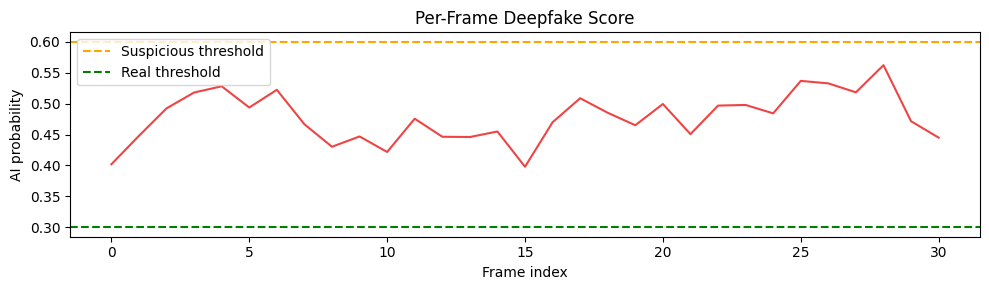


📊 Visual deepfake score: 0.478


In [8]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
import urllib.request

# ── Device ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Load pretrained EfficientNet-B0 as backbone ──
backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
backbone.classifier[1] = nn.Linear(backbone.classifier[1].in_features, 2)  # Real vs AI
backbone = backbone.to(device).eval()

print("⚠  Using ImageNet pretrained weights (not deepfake fine-tuned).")
print("   Replace with FaceForensics++ weights for production accuracy.")

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ── Face detector setup ──────────────────────────────────────────────────────
# Try the new mediapipe.tasks API first; fall back to OpenCV Haar cascade.

_USE_MP_TASKS = False
_face_detector = None

try:
    import mediapipe as mp
    BaseOptions = mp.tasks.BaseOptions
    FaceDetector = mp.tasks.vision.FaceDetector
    FaceDetectorOptions = mp.tasks.vision.FaceDetectorOptions
    VisionRunningMode = mp.tasks.vision.RunningMode

    # Download the official face-detection model (.task bundle)
    _MODEL_URL = (
        "https://storage.googleapis.com/mediapipe-models/"
        "face_detector/blaze_face_short_range/float16/latest/"
        "blaze_face_short_range.tflite"
    )
    _MODEL_PATH = os.path.join(WORK_DIR, "blaze_face_short_range.tflite")
    if not os.path.exists(_MODEL_PATH):
        print("Downloading MediaPipe face-detection model …")
        urllib.request.urlretrieve(_MODEL_URL, _MODEL_PATH)

    _fd_options = FaceDetectorOptions(
        base_options=BaseOptions(model_asset_path=_MODEL_PATH),
        running_mode=VisionRunningMode.IMAGE,
        min_detection_confidence=0.5,
    )
    _face_detector = FaceDetector.create_from_options(_fd_options)
    _USE_MP_TASKS = True
    print("✅ Using MediaPipe Tasks face detector")
except Exception as mp_err:
    print(f"⚠  MediaPipe Tasks unavailable ({mp_err})")
    print("   Falling back to OpenCV Haar cascade face detector")


def _detect_faces_mp(img_rgb):
    """Detect faces via MediaPipe Tasks. Returns list of (x1,y1,x2,y2)."""
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result = _face_detector.detect(mp_image)
    h, w = img_rgb.shape[:2]
    boxes = []
    for det in result.detections:
        bb = det.bounding_box
        boxes.append((bb.origin_x, bb.origin_y,
                       bb.origin_x + bb.width,
                       bb.origin_y + bb.height))
    return boxes


# OpenCV Haar cascade fallback
_haar_cascade = None
if not _USE_MP_TASKS:
    _haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    _haar_cascade = cv2.CascadeClassifier(_haar_path)
    if _haar_cascade.empty():
        print("⚠  Could not load Haar cascade – face detection disabled")
        _haar_cascade = None
    else:
        print("✅ Using OpenCV Haar cascade face detector")


def _detect_faces_haar(img_rgb):
    """Detect faces via OpenCV Haar cascade. Returns list of (x1,y1,x2,y2)."""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    rects = _haar_cascade.detectMultiScale(gray, scaleFactor=1.1,
                                            minNeighbors=5, minSize=(60, 60))
    return [(x, y, x + w, y + h) for (x, y, w, h) in rects]


def detect_faces(img_rgb):
    if _USE_MP_TASKS:
        return _detect_faces_mp(img_rgb)
    elif _haar_cascade is not None:
        return _detect_faces_haar(img_rgb)
    return []


# ── Per-frame scoring ────────────────────────────────────────────────────────

stage3_findings = []
per_frame_scores = []
suspicious_frame_path = None
best_face_img = None

SOFTMAX = nn.Softmax(dim=1)

print(f"\nProcessing {len(frame_paths)} frames...")

for i, fp in enumerate(frame_paths):
    img_bgr = cv2.imread(fp)
    if img_bgr is None:
        continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    boxes = detect_faces(img_rgb)

    if boxes:
        x1, y1, x2, y2 = boxes[0]
        x1, y1 = max(0, int(x1)), max(0, int(y1))
        x2, y2 = min(w, int(x2)), min(h, int(y2))
        face_crop = img_rgb[y1:y2, x1:x2]

        if face_crop.size == 0:
            continue

        face_pil = Image.fromarray(face_crop)
        inp = transform(face_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = backbone(inp)
            probs = SOFTMAX(logits)[0]

        ai_score = probs[1].item()
        per_frame_scores.append(ai_score)

        if ai_score > 0.6 and suspicious_frame_path is None:
            suspicious_frame_path = fp
            best_face_img = face_pil

# Clean up mediapipe detector
if _USE_MP_TASKS and _face_detector is not None:
    _face_detector.close()

if per_frame_scores:
    visual_score = float(np.mean(per_frame_scores))
    max_score = float(np.max(per_frame_scores))
    frames_with_face = len(per_frame_scores)
else:
    visual_score, max_score, frames_with_face = 0.0, 0.0, 0
    stage3_findings.append("No face detected in any frame")

print(f"\n  Frames with detected face: {frames_with_face}/{len(frame_paths)}")
print(f"  Mean AI score : {visual_score:.3f}")
print(f"  Peak AI score : {max_score:.3f}")

if visual_score > 0.65:
    stage3_findings.append(f"Facial boundary artifacts detected (mean score: {visual_score:.2f})")
if max_score > 0.8:
    stage3_findings.append("Highly suspicious frame(s) detected")

# Plot score distribution
plt.figure(figsize=(10, 3))
plt.plot(per_frame_scores, color="#ef4444", linewidth=1.5)
plt.axhline(0.6, color="orange", linestyle="--", label="Suspicious threshold")
plt.axhline(0.3, color="green",  linestyle="--", label="Real threshold")
plt.xlabel("Frame index")
plt.ylabel("AI probability")
plt.title("Per-Frame Deepfake Score")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n📊 Visual deepfake score: {visual_score:.3f}")

## 🎵 Cell 7 — Stage 4: Audio Analysis
Extracts audio and detects synthetic voice characteristics using librosa.

─── Audio Features ──────────────────────────
  MFCC std-dev         : 44.6698
  Zero Crossing Rate   : 0.0643
  Spectral Centroid    : 1231.6 Hz
  Spectral Rolloff     : 2504.6 Hz


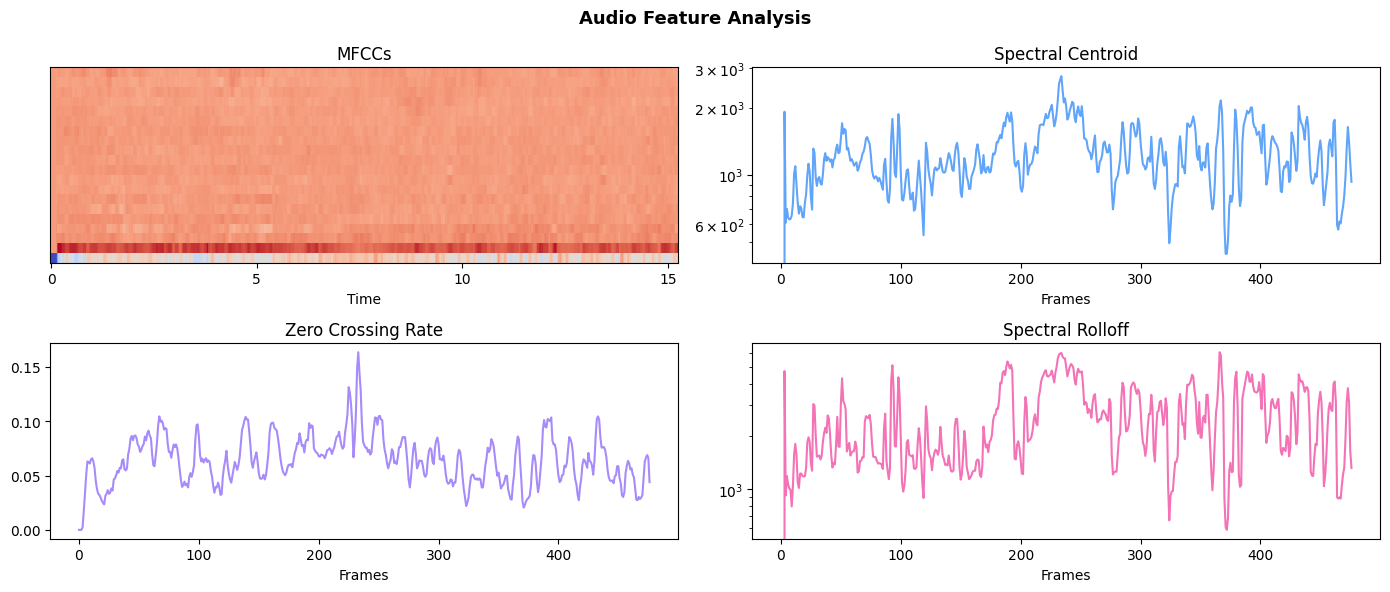


⚠  Audio findings: 0

📊 Audio score: 0.000


In [9]:
import librosa
import librosa.display
import warnings
warnings.filterwarnings("ignore")

stage4_findings = []
audio_score     = 0.0

# Extract audio track from video
extract_cmd = (
    f"ffmpeg -y -loglevel error -i '{VIDEO_PATH}' "
    f"-vn -acodec pcm_s16le -ar 16000 -ac 1 '{AUDIO_PATH}'"
)
ret = os.system(extract_cmd)

if ret != 0 or not os.path.exists(AUDIO_PATH):
    print("⚠  Audio extraction failed or no audio track found.")
    print("   Assigning neutral audio score: 0.0")
else:
    y, sr = librosa.load(AUDIO_PATH, sr=16000, mono=True)

    # ── Feature extraction ──
    mfccs            = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    zero_cr          = librosa.feature.zero_crossing_rate(y)[0]
    spectral_rolloff  = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    spectral_bw       = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]

    mfcc_std  = float(np.std(mfccs))
    zcr_mean  = float(np.mean(zero_cr))
    sc_mean   = float(np.mean(spectral_centroid))
    sr_mean   = float(np.mean(spectral_rolloff))

    print("─── Audio Features ──────────────────────────")
    print(f"  MFCC std-dev         : {mfcc_std:.4f}")
    print(f"  Zero Crossing Rate   : {zcr_mean:.4f}")
    print(f"  Spectral Centroid    : {sc_mean:.1f} Hz")
    print(f"  Spectral Rolloff     : {sr_mean:.1f} Hz")

    # ── Heuristic scoring for synthetic voice ──
    # Real speech: high MFCC variance, moderate ZCR
    # TTS/synthetic: unnaturally low MFCC variance, abnormal spectral shape
    score_contrib = 0.0

    if mfcc_std < 8.0:
        score_contrib += 0.35
        stage4_findings.append(f"Low MFCC variance ({mfcc_std:.2f}) — consistent with synthetic voice")

    if zcr_mean < 0.02:
        score_contrib += 0.2
        stage4_findings.append("Abnormally low zero-crossing rate — atypical for natural speech")

    if sc_mean > 4000:
        score_contrib += 0.2
        stage4_findings.append(f"Elevated spectral centroid ({sc_mean:.0f} Hz) — possible TTS artifact")

    if sr_mean < 2000:
        score_contrib += 0.25
        stage4_findings.append(f"Low spectral rolloff ({sr_mean:.0f} Hz) — narrow frequency range")

    audio_score = min(score_contrib, 1.0)

    # ── Visualize ──
    fig, axes = plt.subplots(2, 2, figsize=(14, 6))
    librosa.display.specshow(mfccs, sr=sr, ax=axes[0,0], x_axis="time")
    axes[0,0].set_title("MFCCs")

    axes[0,1].semilogy(spectral_centroid.T, color='#60a5fa')
    axes[0,1].set(title="Spectral Centroid", xlabel="Frames")

    axes[1,0].plot(zero_cr.T, color='#a78bfa')
    axes[1,0].set(title="Zero Crossing Rate", xlabel="Frames")

    axes[1,1].semilogy(spectral_rolloff.T, color='#f472b6')
    axes[1,1].set(title="Spectral Rolloff", xlabel="Frames")

    plt.suptitle("Audio Feature Analysis", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(f"\n⚠  Audio findings: {len(stage4_findings)}")
for f in stage4_findings:
    print("   •", f)
print(f"\n📊 Audio score: {audio_score:.3f}")

## 📡 Cell 8 — Stage 5: FFT Frequency Analysis
Detects GAN artifact signatures using 2D Fast Fourier Transform.

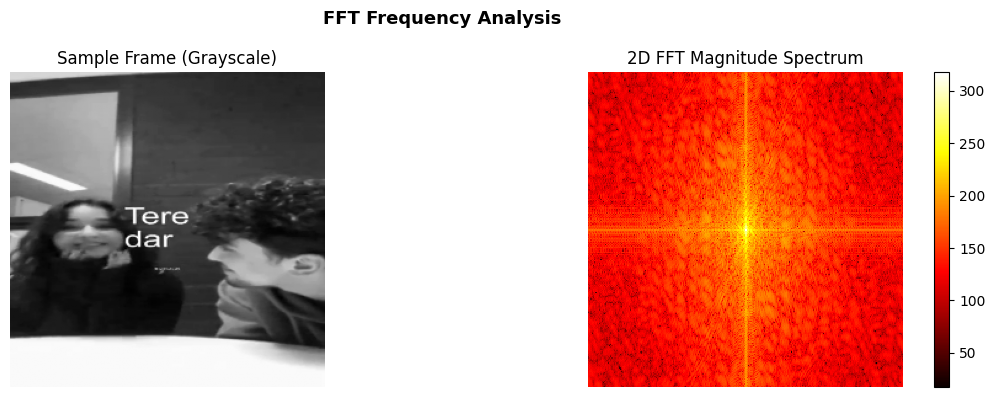

⚠  FFT findings: 1
   • GAN frequency noise detected (FFT score: 0.56)

📊 FFT score: 0.564


In [10]:
stage5_findings = []
fft_score = 0.0
fft_scores_per_frame = []

SAMPLE_FRAMES = frame_paths[::max(1, len(frame_paths)//20)]  # sample up to 20 frames

def compute_fft_score(img_path):
    """
    Compute a GAN-artifact score from 2D FFT.
    GAN-generated images show periodic high-frequency grid patterns
    (upsampling artifacts) not present in real photographs.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0.0

    # Resize for consistency
    img = cv2.resize(img, (256, 256)).astype(np.float32)

    # Compute magnitude spectrum
    dft   = np.fft.fft2(img)
    shift = np.fft.fftshift(dft)
    mag   = 20 * np.log(np.abs(shift) + 1e-8)

    # High-frequency energy ratio
    h, w = mag.shape
    cx, cy = h // 2, w // 2
    outer_ring = mag.copy()
    outer_ring[cx-30:cx+30, cy-30:cy+30] = 0  # zero out DC center

    total_energy   = np.sum(np.abs(mag))
    hf_energy      = np.sum(np.abs(outer_ring))
    hf_ratio       = hf_energy / (total_energy + 1e-8)

    # Detect periodic spikes (GAN upsampling grid)
    flat = outer_ring.flatten()
    spike_thresh = np.percentile(flat, 98)
    spike_count  = np.sum(flat > spike_thresh)
    spike_density = spike_count / len(flat)

    # Combine into score
    raw = (hf_ratio * 0.5) + (spike_density * 10 * 0.5)
    return float(min(raw, 1.0))


fft_scores_per_frame = [compute_fft_score(fp) for fp in SAMPLE_FRAMES]
fft_score = float(np.mean(fft_scores_per_frame)) if fft_scores_per_frame else 0.0

# Visualize FFT of a sample frame
sample_img = cv2.imread(SAMPLE_FRAMES[len(SAMPLE_FRAMES)//2], cv2.IMREAD_GRAYSCALE)
if sample_img is not None:
    sample_img = cv2.resize(sample_img, (256, 256)).astype(np.float32)
    dft   = np.fft.fft2(sample_img)
    shift = np.fft.fftshift(dft)
    mag   = 20 * np.log(np.abs(shift) + 1e-8)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(sample_img, cmap="gray")
    axes[0].set_title("Sample Frame (Grayscale)")
    axes[0].axis("off")

    im = axes[1].imshow(mag, cmap="hot", interpolation="nearest")
    axes[1].set_title("2D FFT Magnitude Spectrum")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1])
    plt.suptitle("FFT Frequency Analysis", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

if fft_score > 0.55:
    stage5_findings.append(f"GAN frequency noise detected (FFT score: {fft_score:.2f})")
if fft_score > 0.75:
    stage5_findings.append("Strong periodic grid patterns — high-confidence GAN upsampling artifact")

print(f"⚠  FFT findings: {len(stage5_findings)}")
for f in stage5_findings:
    print("   •", f)
print(f"\n📊 FFT score: {fft_score:.3f}")

## 🔥 Cell 9 — Stage 6: XAI — Grad-CAM Heatmap
Generates a Grad-CAM visualization highlighting suspicious facial regions.

No suspicious face found — using middle frame for Grad-CAM


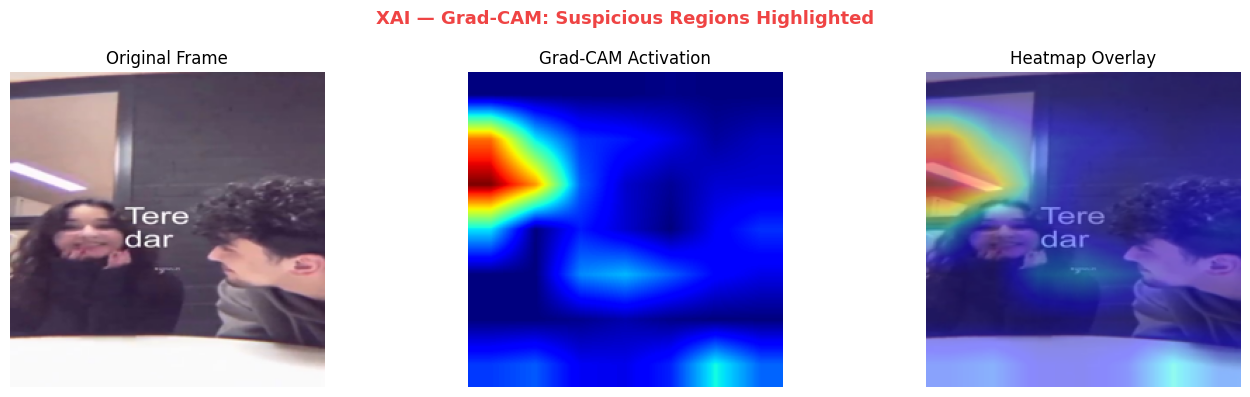

✅ Heatmap saved → /kaggle/working/heatmap.jpg


In [11]:
import torch.nn.functional as F
import matplotlib.cm as cm

heatmap_generated = False

# ── Grad-CAM implementation ──
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.gradients    = None
        self.activations  = None
        self._register(target_layer)

    def _register(self, layer):
        layer.register_forward_hook(self._save_activation)
        layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, mod, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, mod, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor, class_idx=1):
        """class_idx=1 → AI-generated class."""
        self.model.zero_grad()
        output = self.model(input_tensor)
        loss   = output[0, class_idx]
        loss.backward()

        # Global average pooling over spatial dims
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)
        cam     = F.interpolate(cam, size=(224, 224), mode="bilinear", align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        cam    -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam


# Target: last conv block in EfficientNet-B0
target_layer = backbone.features[-1]
grad_cam     = GradCAM(backbone, target_layer)
backbone.eval()

# Use the most suspicious face image, or the middle frame as fallback
if best_face_img is not None:
    source_img = best_face_img
    print("Using most suspicious face crop for Grad-CAM")
elif frame_paths:
    fallback = cv2.imread(frame_paths[len(frame_paths)//2])
    source_img = Image.fromarray(cv2.cvtColor(fallback, cv2.COLOR_BGR2RGB))
    print("No suspicious face found — using middle frame for Grad-CAM")
else:
    print("⚠  No frames available for Grad-CAM.")
    source_img = None

if source_img is not None:
    inp = transform(source_img).unsqueeze(0).to(device)
    inp.requires_grad_(True)

    cam_map = grad_cam.generate(inp, class_idx=1)

    # Overlay on original image
    orig = np.array(source_img.resize((224, 224))).astype(np.uint8)
    colormap = cm.get_cmap("jet")
    heatmap_rgba  = colormap(cam_map)                         # H×W×4
    heatmap_rgb   = (heatmap_rgba[:, :, :3] * 255).astype(np.uint8)
    overlay       = (orig * 0.55 + heatmap_rgb * 0.45).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(orig)
    axes[0].set_title("Original Frame")
    axes[0].axis("off")

    axes[1].imshow(cam_map, cmap="jet")
    axes[1].set_title("Grad-CAM Activation")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("Heatmap Overlay")
    axes[2].axis("off")

    plt.suptitle("XAI — Grad-CAM: Suspicious Regions Highlighted",
                 fontsize=13, fontweight="bold", color="#ef4444")
    plt.tight_layout()
    plt.savefig(HEATMAP_OUT, dpi=150, bbox_inches="tight")
    plt.show()
    heatmap_generated = True
    print(f"✅ Heatmap saved → {HEATMAP_OUT}")

## 📊 Cell 10 — Ensemble Scoring, Manipulation Classification & Report
Combines all stage scores into a final authenticity probability, **classifies the type of manipulation** (deepfake / misinformation / out-of-context / voice-clone / GAN-generated), and writes `report.json`.

In [12]:
import json

# ── Weighted ensemble ─────────────────────────────────────────────────────────
# Semantic gets the HIGHEST weight — misinformation / fabricated-event detection
# is our primary goal.  Visual (pixel-level deepfake) is secondary.
WEIGHTS = {
    "semantic": 0.45,   # VQA + CLIP + event-likelihood + face-ID plausibility
    "visual":   0.20,   # pixel-level deepfake artifacts (CNN)
    "audio":    0.13,   # synthetic voice detection
    "fft":      0.13,   # GAN frequency artifacts
    "metadata": 0.09,   # file-level anomalies
}

scores = {
    "semantic": semantic_score,
    "visual":   visual_score,
    "audio":    audio_score,
    "fft":      fft_score,
    "metadata": metadata_score,
}

ai_probability = sum(scores[k] * WEIGHTS[k] for k in WEIGHTS)
ai_probability = round(float(ai_probability), 4)

print("─── Stage Scores ────────────────────────────")
for k in WEIGHTS:
    v = scores[k]
    bar = "█" * int(v * 30) + "░" * (30 - int(v * 30))
    w = WEIGHTS[k]
    print(f"  {k:10s}: {bar}  {v:.3f}  (w={w:.0%})")
print(f"  {'COMBINED':10s}: {'█' * int(ai_probability * 30)}  {ai_probability:.3f}")

# ── Determine manipulation TYPE ──────────────────────────────────────────────
# Not all fakes are deepfakes — classify what kind of manipulation we suspect
manipulation_type = "none"
type_reasons = []

if semantic_score >= 0.5 and visual_score < 0.4:
    manipulation_type = "misinformation"
    type_reasons.append("High semantic risk with low pixel-level artifacts → likely real footage used as misinformation")
elif semantic_score >= 0.3 and visual_score >= 0.5:
    manipulation_type = "deepfake + misinformation"
    type_reasons.append("Both semantic implausibility and visual artifacts detected")
elif visual_score >= 0.5 and semantic_score < 0.3:
    manipulation_type = "deepfake"
    type_reasons.append("Visual artifacts detected but scenario is plausible → likely face-swap or synthetic generation")
elif fft_score >= 0.6:
    manipulation_type = "GAN-generated"
    type_reasons.append("Strong FFT frequency artifacts consistent with GAN generation")
elif audio_score >= 0.5 and visual_score < 0.3:
    manipulation_type = "voice-cloned"
    type_reasons.append("Synthetic audio detected on otherwise authentic-looking video")
elif any("out-of-context" in f.lower() for f in stage2_5_findings):
    manipulation_type = "out-of-context"
    type_reasons.append("Real footage potentially presented in misleading context")
elif ai_probability >= 0.3:
    manipulation_type = "suspicious"
    type_reasons.append("Multiple mild signals — cannot determine specific manipulation type")

# ── Risk level ────────────────────────────────────────────────────────────────
if ai_probability < 0.20:
    risk_level = "Likely Authentic"
    confidence = "High"
elif ai_probability < 0.40:
    risk_level = "Low Risk"
    confidence = "Medium"
elif ai_probability < 0.60:
    risk_level = "Suspicious"
    confidence = "Medium"
elif ai_probability < 0.80:
    risk_level = "High Risk — Likely Manipulated"
    confidence = "High"
else:
    risk_level = "Critical — Almost Certainly Fake/Fabricated"
    confidence = "Very High"

# ── Consolidate evidence ──────────────────────────────────────────────────────
all_evidence = (
    stage2_5_findings    # semantic (most important)
    + stage3_findings    # visual CNN
    + stage1_findings    # metadata
    + stage4_findings    # audio
    + stage5_findings    # FFT
)
if not all_evidence:
    all_evidence = ["No significant artifacts or semantic anomalies detected"]

# ── Summary ──────────────────────────────────────────────────────────────────
if manipulation_type == "none":
    summary_text = (
        f"No significant manipulation signals detected across all analysis stages. "
        f"Content appears authentic. Combined score: {ai_probability:.0%}."
    )
elif manipulation_type == "misinformation":
    summary_text = (
        f"⚠ Semantic analysis flagged this content as likely MISINFORMATION. "
        f"The video itself may be real, but it depicts an implausible or fabricated "
        f"scenario. Combined score: {ai_probability:.0%}."
    )
elif manipulation_type == "out-of-context":
    summary_text = (
        f"⚠ This appears to be REAL footage potentially used OUT OF CONTEXT. "
        f"The video pixels are authentic, but the framing or attribution may be "
        f"misleading. Combined score: {ai_probability:.0%}."
    )
elif manipulation_type == "deepfake":
    summary_text = (
        f"🚩 Visual analysis detected DEEPFAKE artifacts (face manipulation / "
        f"synthetic generation). Combined score: {ai_probability:.0%}."
    )
elif manipulation_type == "deepfake + misinformation":
    summary_text = (
        f"🚨 BOTH deepfake artifacts AND semantic implausibility detected. "
        f"Content is very likely fabricated with AI. Combined score: {ai_probability:.0%}."
    )
elif manipulation_type == "GAN-generated":
    summary_text = (
        f"🚩 FFT analysis shows strong GAN upsampling artifacts. Content is likely "
        f"AI-GENERATED. Combined score: {ai_probability:.0%}."
    )
elif manipulation_type == "voice-cloned":
    summary_text = (
        f"⚠ Audio analysis suggests SYNTHETIC/CLONED VOICE on otherwise authentic-"
        f"looking video. Combined score: {ai_probability:.0%}."
    )
else:
    summary_text = (
        f"Multiple mild signals detected across analysis stages. Content warrants "
        f"caution but manipulation type is inconclusive. Combined score: {ai_probability:.0%}."
    )

# ── Build report ──────────────────────────────────────────────────────────────
report = {
    "ai_probability":     ai_probability,
    "confidence":         confidence,
    "risk_level":         risk_level,
    "manipulation_type":  manipulation_type,
    "type_reasons":       type_reasons,
    "summary":            summary_text,
    "evidence":           all_evidence,
    "heatmap_image":      "heatmap.jpg" if heatmap_generated else None,
    "stage_scores": {
        "semantic_plausibility":  round(semantic_score, 4),
        "visual_deepfake":        round(visual_score, 4),
        "audio_synthetic":        round(audio_score, 4),
        "fft_gan_artifact":       round(fft_score, 4),
        "metadata_anomaly":       round(metadata_score, 4),
    },
    "identified_people": [
        {"name": n, "frame": int(f), "confidence": c}
        for (f, n, c) in _identified_faces
    ],
    "frame_captions":     _captions,
    "clip_classifications": [
        {"frame": int(f), "label": l, "confidence": round(p, 3)}
        for (f, l, p) in _clip_labels
    ],
    "vqa_answers": [
        {"frame": int(f), "question": q, "answer": a}
        for (f, q, a) in _vqa_answers
    ],
    "event_likelihood": [
        {"frame": int(f), "scenario": s, "claimed_score": round(cs, 4),
         "normal_score": round(ns, 4), "delta": round(d, 4)}
        for (f, s, cs, ns, d) in _event_scores
    ],
    "source_url":         VIDEO_URL,
    "platform":           PLATFORM,
}

with open(REPORT_OUT, "w") as f:
    json.dump(report, f, indent=2)

print(f"\n✅ Report saved → {REPORT_OUT}")
print()
print("═" * 60)
print("  🛡️  VerifAI — Content Authenticity Report")
print("═" * 60)
print(f"  Combined Score   : {ai_probability:.0%}")
print(f"  Risk Level       : {risk_level}")
print(f"  Manipulation Type: {manipulation_type.upper() if manipulation_type != 'none' else '—'}")
print(f"  Confidence       : {confidence}")
print(f"  Heatmap          : {'heatmap.jpg' if heatmap_generated else 'N/A'}")
if _identified_faces:
    names = sorted(set(n for (_, n, _) in _identified_faces))
    print(f"  People Identified: {', '.join(names)}")
print("═" * 60)
if type_reasons:
    print(f"  Reasoning:")
    for r in type_reasons:
        print(f"    → {r}")
    print("─" * 60)
print(f"  Evidence ({len(all_evidence)} findings):")
for e in all_evidence:
    print(f"    • {e}")
print("═" * 60)

─── Stage Scores ────────────────────────────
  semantic  : ██████████████████░░░░░░░░░░░░  0.602  (w=45%)
  visual    : ██████████████░░░░░░░░░░░░░░░░  0.478  (w=20%)
  audio     : ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  0.000  (w=13%)
  fft       : ████████████████░░░░░░░░░░░░░░  0.564  (w=13%)
  metadata  : ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  0.000  (w=9%)
  COMBINED  : █████████████  0.440

✅ Report saved → /kaggle/working/report.json

════════════════════════════════════════════════════════════
  🛡️  VerifAI — Content Authenticity Report
════════════════════════════════════════════════════════════
  Combined Score   : 44%
  Risk Level       : Suspicious
  Manipulation Type: SUSPICIOUS
  Confidence       : Medium
  Heatmap          : heatmap.jpg
════════════════════════════════════════════════════════════
  Reasoning:
    → Multiple mild signals — cannot determine specific manipulation type
────────────────────────────────────────────────────────────
  Evidence (5 findings):
    • VQA detected

## 📤 Cell 11 — Push Report to Backend (Optional)
If you have a `job_id` from the Flask backend, this cell POSTs the report back so the extension can retrieve it.

In [13]:
# ── OPTIONAL: Push report back to your Flask backend ─────────────────────────
# Set BACKEND_URL and JOB_ID before running this cell.

BACKEND_URL = "http://localhost:5000"   # change to your deployed backend URL
JOB_ID      = ""                        # paste the job_id returned by POST /scan

if JOB_ID:
    try:
        resp = requests.post(
            f"{BACKEND_URL}/reports/{JOB_ID}",
            json=report,
            timeout=10,
        )
        if resp.status_code == 200:
            print(f"✅ Report pushed to backend (job_id={JOB_ID})")
            print(f"   Extension can now retrieve: GET {BACKEND_URL}/reports/{JOB_ID}")
        else:
            print(f"⚠  Backend returned: {resp.status_code} — {resp.text}")
    except Exception as e:
        print(f"⚠  Could not reach backend: {e}")
else:
    print("JOB_ID not set — skipping backend push.")
    print("Download report.json from the Kaggle output panel manually.")

JOB_ID not set — skipping backend push.
Download report.json from the Kaggle output panel manually.
